**TAREA**: Sin herramientas de IA, crea una imagen, p.e. de 800x800 píxeles, con la textura del tablero de ajedrez.
Una vez resuelto de forma manual, resuelve la misma tarea usando un asistente de IA de tu elección (Claude, ChatGPT, Copilot, etc...). Compara ambas versiones en el informe de la práctica.

In [6]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

Forma manual:

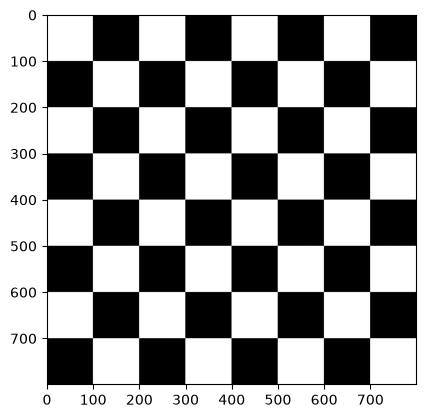

In [2]:
#Dimensiones de la imagen a crear
ancho = 800
alto = 800

# Crear imagen negra de 800x800 como base del tabero
tablero_ajedrez = np.zeros((alto,ancho,1), dtype = np.uint8)

# Tamaño de cada casilla
tamaño = 100

# Crear el tablero alternando casillas blancas y negras
for i in range(0, alto, tamaño):
    for j in range(0, ancho, tamaño):
        if (i // tamaño + j // tamaño) % 2 == 0:
            tablero_ajedrez[i:i+tamaño, j:j+tamaño] = 255

# Mostrar la imagen
plt.imshow(tablero_ajedrez, cmap='gray')
plt.show()

Asistente IA:

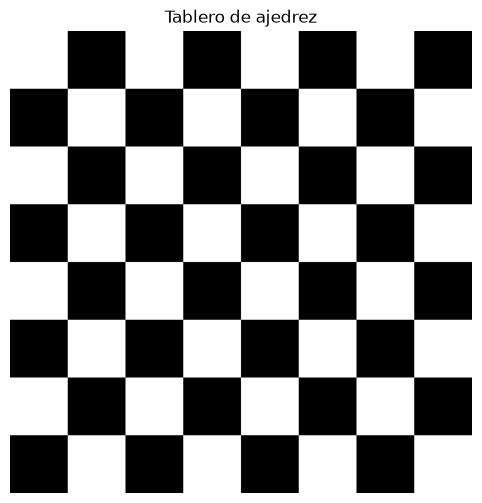

In [29]:
# Definición del patrón base 2x2:
# [255,   0]
# [  0, 255]
patron_base = np.array([[255, 0], [0, 255]], dtype=np.uint8)

# Replicar el bloque 2x2 cuatro veces en cada eje -> tablero 8x8
patron_8x8 = np.tile(patron_base, (4, 4))

# Escalar cada celda a 100x100 píxeles usando producto de Kronecker (800x800 total)
tablero = np.kron(patron_8x8, np.ones((100, 100), dtype=np.uint8))

# Visualización
plt.figure(figsize=(6, 6))
plt.imshow(tablero, cmap='gray', vmin=0, vmax=255)
plt.title("Tablero de ajedrez")
plt.axis('off')
plt.show()

**TAREA**: Crear una imagen estilo Mondrian (un ejemplo https://www3.gobiernodecanarias.org/medusa/ecoescuela/sa/2017/04/17/descubriendo-a-mondrian/) con las funciones de dibujo de OpenCV.
No hagas uso de herramientas de IA, parte del ejemplo anterior.

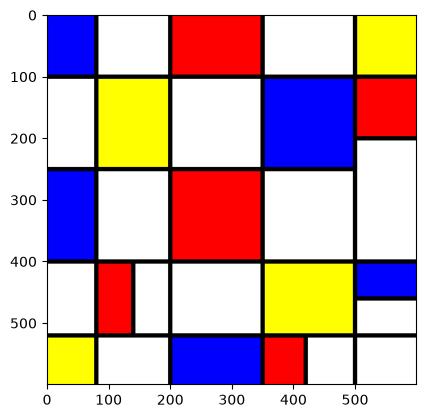

In [ ]:
ancho = 600
alto = 600

mondrian = np.zeros((alto, ancho, 3), dtype=np.uint8)

# Fondo blanco
mondrian[:] = 255

rojo = (255, 0, 0)
amarillo = (255, 255, 0)
azul = (0, 0, 255)
negro = (0, 0, 0)

# Rectángulos
cv2.rectangle(mondrian, (0, 0), (400, 400), rojo, -1)
cv2.rectangle(mondrian, (400, 0), (600, 150), amarillo, -1)
cv2.rectangle(mondrian, (250, 400), (400, 600), azul, -1)

# Líneas Verticales
cv2.line(mondrian, (400, 0), (400, 600), negro, 8)
cv2.line(mondrian, (250, 400), (250, 600), negro, 8)

# Líneas Horizontales
cv2.line(mondrian, (0, 400), (600, 400), negro, 8)
cv2.line(mondrian, (400, 150), (600, 150), negro, 8)

# Mostrar la imagen
plt.imshow(mondrian)
plt.show()

**TAREA**:
Pintar círculos en las posiciones del píxel más claro y oscuro de cada fotograma captado por la cámara. ¿Funciona de forma fluida o a saltos? En el segundo caso, ¿podrías acelerarlo?
Si haces uso de herramientas de IA, incluye la conversación.


In [ ]:
vid = cv2.VideoCapture(0)

# Tipografía para mostrar texto
font = cv2.FONT_HERSHEY_SIMPLEX

contador = 0


while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret: 

        # Convertir a escala de grises para evaluar el brillo
        gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Calcular solo cada 5 fotogramas para acelerarlo
        if contador % 5 == 0:
            # Localizar las posiciones del píxel más oscuro y más claro
            min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(gris)

        # Píxel más oscuro con círculo azul
        cv2.circle(frame, min_loc, 10, (255, 0, 0), 2)
        cv2.putText(frame, f'Min: {int(min_val)}', (min_loc[0] + 12, min_loc[1] + 5), font, 0.5, (255, 0, 0), 1)

        # Píxel más claro con círculo rojo
        cv2.circle(frame, max_loc, 10, (0, 0, 255), 2)
        cv2.putText(frame, f'Max: {int(max_val)}', (max_loc[0] + 12, max_loc[1] + 5), font, 0.5, (0, 0, 255), 1)
            
        cv2.imshow('Cam', frame)

        contador += 1


    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

TAREA: Llevar a cabo una propuesta propia de pop art.
Incluye fuentes consultadas. 
Si haces uso de herramientas de IA, incluye la conversación.

In [ ]:
# Iniciamos la cámara
vid = cv2.VideoCapture(0)

# Calculamos dimensiones reducidas a la mitad
w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH) / 2)
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT) / 2)
vid.set(cv2.CAP_PROP_FRAME_WIDTH, w)
vid.set(cv2.CAP_PROP_FRAME_HEIGHT, h)

# Creamos el lienzo negro para el collage y definimos las 4 esquinas
collage = np.zeros((h*2, w*2, 3), dtype=np.uint8)
tl, tr = collage[0:h, 0:w], collage[0:h, w:w+w]
bl, br = collage[h:h+h, 0:w], collage[h:h+h, w:w+w]

while True:      
    # Leemos cada fotograma de la cámara
    ret, frameIN = vid.read()
    if not ret: break

    # Redimensionamos y obtenemos la base en escala de grises
    frame = cv2.resize(frameIN, (w, h), cv2.INTER_NEAREST)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # 1. Arriba Izq (Warhol Suave): Aplicamos mapa de color Magenta/Amarillo
    tl[:] = cv2.applyColorMap(gray, cv2.COLORMAP_SPRING)

    # 2. Arriba Der (Psicodélico): Rotamos y saturamos colores en el espacio HSV
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    h_ch, s_ch, v_ch = cv2.split(hsv)
    h_ch = ((h_ch.astype(np.int16) + 90) % 180).astype(np.uint8)
    tr[:] = cv2.cvtColor(cv2.merge([h_ch, cv2.add(s_ch, 50), v_ch]), cv2.COLOR_HSV2BGR)

    # 3. Abajo Izq (Duotono Pop): Separamos luces (Amarillo) y sombras (Azul)
    _, mask = cv2.threshold(gray, 110, 255, cv2.THRESH_BINARY)
    bl[mask == 255] = [0, 255, 255] # Amarillo en BGR
    bl[mask == 0] = [255, 0, 0]     # Azul en BGR

    # 4. Abajo Der (Neón): Detectamos bordes y los dibujamos en verde brillante
    edges = cv2.Canny(gray, 60, 120)
    edges_neon = cv2.merge([np.zeros_like(edges), edges, np.zeros_like(edges)])
    br[:] = cv2.addWeighted(frame, 0.3, edges_neon, 1.0, 0)

    # Mostramos la composición final en pantalla
    cv2.imshow('Pop Art', collage)
   
    # Salimos al pulsar la tecla ESC
    if cv2.waitKey(20) == 27:
        break
 
# Liberamos la cámara y cerramos ventanas
vid.release()
cv2.destroyAllWindows()